In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD


### Part (a)

In [10]:
file_name = "profiles.mat"

# open the .mat file
with h5py.File(file_name, "r") as f:
    temperature = f['TEMP'][()]
    salinity = f['SAL'][()]
    
# Check the dimensions of the arrays
print("Temperature array dimensions:", temperature.shape)
print("Salinity array dimensions:", salinity.shape)

Temperature array dimensions: (1000, 2001)
Salinity array dimensions: (1000, 2001)


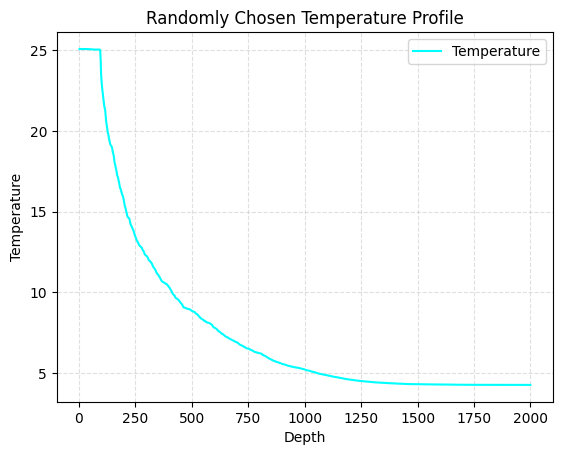

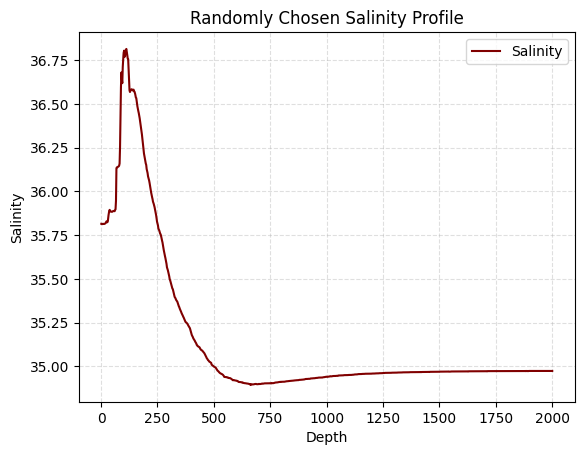

In [11]:
# Plot a randomly chosen temperature profile
random_index = np.random.randint(0, len(temperature))
plt.plot(temperature[random_index], label='Temperature', color= 'cyan')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Randomly Chosen Temperature Profile')
plt.legend()
plt.grid(True, linestyle='--',alpha= 0.4)
plt.show()

# Plot a randomly chosen salinity profile
random_index = np.random.randint(0, len(salinity))
plt.plot(salinity[random_index], label='Salinity', color='maroon')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Randomly Chosen Salinity Profile')
plt.grid(True, linestyle='--',alpha= 0.4)
plt.legend()
plt.show()

### Part (b)

In [14]:
# Reshape data
num_profiles = len(temperature)
num_depths = temperature.shape[1]

temperature_flat = temperature.reshape(num_profiles, num_depths)  # Flatten temperature profiles
salinity_flat = salinity.reshape(num_profiles, num_depths)        # Flatten salinity profiles

# Standardization
temperature_mean = temperature_flat.mean(axis=1, keepdims=True)
temperature_std = temperature_flat.std(axis=1, keepdims=True)
temperature_std[temperature_std == 0] = 1  # Avoid division by zero for constant profiles
temperature_standardized = (temperature_flat - temperature_mean) / temperature_std

salinity_mean = salinity_flat.mean(axis=1, keepdims=True)
salinity_std = salinity_flat.std(axis=1, keepdims=True)
salinity_std[salinity_std == 0] = 1  # Avoid division by zero for constant profiles
salinity_standardized = (salinity_flat - salinity_mean) / salinity_std

# Compute covariance matrices
temperature_covariance = np.dot(temperature_standardized.T, temperature_standardized) / num_profiles
salinity_covariance = np.dot(salinity_standardized.T, salinity_standardized) / num_profiles

# Perform Singular Value Decomposition (SVD)
_, temperature_singular_vectors, _ = np.linalg.svd(temperature_covariance)
_, salinity_singular_vectors, _ = np.linalg.svd(salinity_covariance)

# Select top 400 singular vectors
temperature_reduced = temperature_singular_vectors[:, :400]
salinity_reduced = salinity_singular_vectors[:, :400]

# Reconstruct the profiles using the selected singular vectors
approx_temperature = np.dot(temperature_reduced, temperature_reduced.T)  # Approximation of temperature profiles
approx_salinity = np.dot(salinity_reduced, salinity_reduced.T)          # Approximation of salinity profiles

# Plot a randomly chosen profile along with its corresponding approximation
random_index = np.random.randint(num_profiles)
approx_temperature_profile = approx_temperature[random_index].reshape(num_depths, 1)
approx_salinity_profile = approx_salinity[random_index].reshape(num_depths, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(temperature_flat[random_index], label='Original')
plt.plot(approx_temperature_profile, label='Approximation')
plt.xlabel('Depth')
plt.ylabel('Temperature')
plt.title('Temperature Profile and Approximation')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(salinity_flat[random_index], label='Original')
plt.plot(approx_salinity_profile, label='Approximation')
plt.xlabel('Depth')
plt.ylabel('Salinity')
plt.title('Salinity Profile and Approximation')
plt.legend()

plt.tight_layout()
plt.show()


LinAlgError: SVD did not converge